<a href="https://colab.research.google.com/github/prabhusanika24/CSL701-ce37_Machine-Learning-Lab/blob/main/Experiment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
Name:Sanika Janardan Prabhu
RollNo:CE37

# Machine Learning Experiment Number 3

**Aim** : To implement a Multiple Linear Regression model from scratch using NumPy matrix operations to predict the selling price of used cars using multiple features from the CarDekho Used Car Dataset.


**Learning Outcomes**
•	Understand the working principle of Multiple Linear Regression.

•	Perform data preprocessing and feature engineering.

•	Convert categorical data into numerical features.

•	Standardize numerical features.

•	Implement the Ordinary Least Squares method using matrix operations.

•	Train and test a regression model without using a ready-made regression function.

•	Evaluate and interpret regression performance using RSS and R².

•	Understand the effect of individual features on the predicted price.



\### Dataset

Use the **CarDekho Used Car Dataset** (`car data.csv`). [CarDekho Used Car Dataset](https://www.kaggle.com/datasets/manishkr1754/cardekho-used-car-data)

Explain meaning of each attribute in this dataset in below comment section :


Here, **Selling_Price** is the target variable.





\# Software/Tools Required

- Python 3.x
- Google Colab / Jupyter Notebook
- NumPy
- Matplotlib

---


### Task 1: Set Up the Python Environment**

- Create a new Google Colab notebook.
- Import **NumPy** for numerical and matrix operations.
- Import **Matplotlib** for data visualization.
- Do not use ready-made machine-learning regression functions such as `LinearRegression()` from Scikit-learn.
- The regression model must be implemented using matrix operations.

---

In [ ]:
# Task 1: Set Up the Python Environment

# Import NumPy for numerical and matrix operations
import numpy as np

# Import Matplotlib for data visualization
import matplotlib.pyplot as plt

print("Python environment is ready!")
print("NumPy version:", np.__version__)

Python environment is ready!
NumPy version: 2.0.2


## Task 2: Load and Inspect the Dataset

- Download the `car data.csv` file.
- Upload the dataset to Google Colab.
- Load the dataset into Python.
- Display the first few records.
- Determine the number of rows and columns.
- Identify the numerical and categorical attributes.
- Separate `Selling_Price` as the target variable.

---

In [ ]:
# Task 2: Load and Inspect the Dataset

import pandas as pd
from google.colab import files
import zipfile
import os

# Upload the dataset (this line is kept for user interaction, but the agent will handle unzipping)
# uploaded = files.upload()

# Assuming the uploaded file is 'archive.zip' as per kernel state
zip_file_name = 'archive.zip'

# Unzip the file
if os.path.exists(zip_file_name):
    with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
        zip_ref.extractall('.')
    print(f"'{zip_file_name}' unzipped successfully.")

# Now load the CSV file, which is named 'cardekho_dataset.csv' inside the archive
df = pd.read_csv('cardekho_dataset.csv')

# Display first 5 records
print("First 5 records:")
display(df.head())

# Display number of rows and columns
print("Number of rows and columns:", df.shape)

# Display column names
print("\nColumn names:")
print(df.columns.tolist())

# Identify numerical attributes
numerical_attributes = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Identify categorical attributes
categorical_attributes = df.select_dtypes(include=['object']).columns.tolist()

print("\nNumerical attributes:")
print(numerical_attributes)

print("\nCategorical attributes:")
print(categorical_attributes)

# Separate selling_price as target variable
y = df['selling_price']

# Display target variable
print("\nTarget variable: selling_price")
print(y.head())

'archive.zip' unzipped successfully.
First 5 records:


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


Number of rows and columns: (15411, 14)

Column names:
['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

Numerical attributes:
['Unnamed: 0', 'vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

Categorical attributes:
['car_name', 'brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']

Target variable: selling_price
0    120000
1    550000
2    215000
3    226000
4    570000
Name: selling_price, dtype: int64


In [ ]:
# Check for missing values
print("Missing values before handling:")
display(df.isnull().sum())

Missing values before handling:


,0
Unnamed: 0,0
car_name,0
brand,0
model,0
vehicle_age,0
km_driven,0
seller_type,0
fuel_type,0
transmission_type,0
mileage,0


## Task 3: Check and Handle Missing Data

- Check every attribute for missing or null values.
- Count the number of missing values in each column.
- If missing values are present, either remove incomplete records or perform suitable imputation.
- Verify that the final dataset does not contain missing values.
- Record the preprocessing method used.

---

In [ ]:
# Task 3: Check and Handle Missing Data

# Check missing values in each column
print("Missing values in each column:")
print(df.isnull().sum())

# Check total number of missing values
print("\nTotal missing values:")
print(df.isnull().sum().sum())

# Handle missing values
if df.isnull().sum().sum() > 0:
    # Remove rows containing missing values
    df = df.dropna()
    print("\nMissing values were found and incomplete rows were removed.")
else:
    print("\nNo missing values were found. No data removal was required.")

# Verify that no missing values remain
print("\nMissing values after preprocessing:")
print(df.isnull().sum())

print("\nTotal missing values after preprocessing:")
print(df.isnull().sum().sum())

Missing values in each column:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

Total missing values:
0

No missing values were found. No data removal was required.

Missing values after preprocessing:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

Total missing values after preprocessing:
0


## Task 4: Select and Prepare Features

- Examine all available attributes.
- Decide how `Car_Name` should be handled.
- Select meaningful predictor variables for the regression model.
- Create the predictor matrix $X$ and target vector $y$.
- Record the final list of features selected for the model.

---

In [ ]:
# Task 4: Select and Prepare Features

# Display all available attributes
print("Available attributes:")
print(df.columns.tolist())

# Car_Name is not used as a predictor because it is a categorical
# identifier with many unique car names. 'model' also has high cardinality.
# 'Unnamed: 0' is an index column and should be dropped.

# Select meaningful predictor variables
# Correcting column names to match the DataFrame and including relevant ones
features = [
    'vehicle_age',    # Corrected from 'Year'
    'km_driven',      # Corrected from 'Kms_Driven'
    'mileage',
    'engine',
    'max_power',
    'seats',
    'brand',
    'seller_type',    # Corrected from 'Owner' or 'Seller_Type'
    'fuel_type',      # Corrected from 'Fuel_Type'
    'transmission_type' # Corrected from 'Transmission'
]

# Create a new dataframe with selected features
X = df[features]

# Separate target variable
y = df['selling_price'] # Corrected from 'Selling_Price'

# Convert categorical variables into numerical form
# Identify categorical columns from the selected features list
categorical_features_for_encoding = ['brand', 'seller_type', 'fuel_type', 'transmission_type']

X = pd.get_dummies(
    X,
    columns=categorical_features_for_encoding,
    drop_first=True,
    dtype=int
)

# Convert X and y into NumPy arrays for matrix operations
X = X.values
y = y.values

# Display the prepared predictor matrix and target vector
print("\nPredictor matrix X (first 5 rows):")
print(X[:5])

print("\nTarget vector y (first 5 values):")
print(y[:5])

print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

Available attributes:
['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

Predictor matrix X (first 5 rows):
[[9.000e+00 1.200e+05 1.970e+01 7.960e+02 4.630e+01 5.000e+00 0.000e+00
  0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
  0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
  0.000e+00 0.000e+00 1.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
  0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
  0.000e+00 0.000e+00 1.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
  1.000e+00 1.000e+00]
 [5.000e+00 2.000e+04 1.890e+01 1.197e+03 8.200e+01 5.000e+00 0.000e+00
  0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 1.000e+00
  0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
  0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00 0.000e+00
  0.000e+00 0.000

## Task 5: Encode Categorical Variables

Identify the categorical variables:

- `Fuel_Type`
- `Seller_Type`
- `Transmission`

Perform the following:

- Convert categorical variables into numerical **dummy/indicator variables**.
- Verify that all predictors are numerical after encoding.
- Do not assign arbitrary numerical values to categories when such values would imply an incorrect ordering.
- Display the transformed dataset.

---

In [ ]:
# Task 5: Encode Categorical Variables

# Categorical variables
# Correcting column names to match the DataFrame and including 'brand'
categorical_columns = ['fuel_type', 'seller_type', 'transmission_type', 'brand']

print("Categorical variables:")
print(categorical_columns)

# Display unique values before encoding
for column in categorical_columns:
    print(f"\n{column} unique values:")
    print(df[column].unique())

# Perform one-hot encoding
df_encoded = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

# Display transformed dataset
print("\nTransformed Dataset:")
display(df_encoded.head())

# Verify data types of all predictors
print("\nData types after encoding:")
print(df_encoded.dtypes)

# Check whether any categorical columns remain
categorical_after_encoding = df_encoded.select_dtypes(
    include=['object']
).columns.tolist()

print("\nCategorical columns remaining:")
print(categorical_after_encoding)

# Verify that all predictors are numerical
if len(categorical_after_encoding) == 0:
    print("\nAll predictors are numerical after encoding.")
else:
    print("\nSome categorical columns still remain. These are typically high-cardinality identifiers like 'car_name' and 'model' that are generally excluded from direct modeling.")

Categorical variables:
['fuel_type', 'seller_type', 'transmission_type', 'brand']

fuel_type unique values:
['Petrol' 'Diesel' 'CNG' 'LPG' 'Electric']

seller_type unique values:
['Individual' 'Dealer' 'Trustmark Dealer']

transmission_type unique values:
['Manual' 'Automatic']

brand unique values:
['Maruti' 'Hyundai' 'Ford' 'Renault' 'Mini' 'Mercedes-Benz' 'Toyota'
 'Volkswagen' 'Honda' 'Mahindra' 'Datsun' 'Tata' 'Kia' 'BMW' 'Audi'
 'Land Rover' 'Jaguar' 'MG' 'Isuzu' 'Porsche' 'Skoda' 'Volvo' 'Lexus'
 'Jeep' 'Maserati' 'Bentley' 'Nissan' 'ISUZU' 'Ferrari' 'Mercedes-AMG'
 'Rolls-Royce' 'Force']

Transformed Dataset:


,Unnamed: 0,car_name,model,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price,...,brand_Mini,brand_Nissan,brand_Porsche,brand_Renault,brand_Rolls-Royce,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo
0,0,Maruti Alto,Alto,9,120000,19.70,796,46.30,5,120000,...,0,0,0,0,0,0,0,0,0,0
1,1,Hyundai Grand,Grand,5,20000,18.90,1197,82.00,5,550000,...,0,0,0,0,0,0,0,0,0,0
2,2,Hyundai i20,i20,11,60000,17.00,1197,80.00,5,215000,...,0,0,0,0,0,0,0,0,0,0
3,3,Maruti Alto,Alto,9,37000,20.92,998,67.10,5,226000,...,0,0,0,0,0,0,0,0,0,0
4,4,Ford Ecosport,Ecosport,6,30000,22.77,1498,98.59,5,570000,...,0,0,0,0,0,0,0,0,0,0



Data types after encoding:
Unnamed: 0                        int64
car_name                         object
model                            object
vehicle_age                       int64
km_driven                         int64
mileage                         float64
engine                            int64
max_power                       float64
seats                             int64
selling_price                     int64
fuel_type_Diesel                  int64
fuel_type_Electric                int64
fuel_type_LPG                     int64
fuel_type_Petrol                  int64
seller_type_Individual            int64
seller_type_Trustmark Dealer      int64
transmission_type_Manual          int64
brand_BMW                         int64
brand_Bentley                     int64
brand_Datsun                      int64
brand_Ferrari                     int64
brand_Force                       int64
brand_Ford                        int64
brand_Honda                       int64
brand_Hyunda

## Task 6: Perform Feature Engineering

Create a new feature called `Car_Age`.

Calculate it using:

\[
Car\_Age = Current Year - Year
\]

Perform the following:

- Create the `Car_Age` column.
- Display several values of the newly created feature.
- Verify that the calculated ages are reasonable.
- Decide whether the original `Year` feature should be retained.
- Provide a reason for your decision.

---

In [ ]:
# Task 6: Perform Feature Engineering

# Current year (Not directly used if 'vehicle_age' is already the age, but kept for context if needed for other calculations)
current_year = 2026

# Create Car_Age feature using the existing 'vehicle_age' column
df_encoded['Car_Age'] = df_encoded['vehicle_age']

# Display several values of the newly created feature alongside the original 'vehicle_age'
print("Car_Age values (derived from vehicle_age):")
display(df_encoded[['vehicle_age', 'Car_Age']].head(10))

# Check minimum and maximum car age
print("\nMinimum Car Age:", df_encoded['Car_Age'].min())
print("Maximum Car Age:", df_encoded['Car_Age'].max())

# Verify that Car_Age values are reasonable
if (df_encoded['Car_Age'] >= 0).all():
    print("\nCar_Age values are reasonable and non-negative.")
else:
    print("\nSome Car_Age values are negative. Please check the vehicle_age values.")

# Decide whether to retain the original 'vehicle_age' feature
# Since 'Car_Age' now explicitly holds the age, the original 'vehicle_age' can be removed.
df_encoded = df_encoded.drop(columns=['vehicle_age'])

print("\n'vehicle_age' column removed because 'Car_Age' now represents the age of the car.")
print("\nFinal dataset after feature engineering (first 5 rows):")
display(df_encoded.head())

Car_Age values (derived from vehicle_age):


,vehicle_age,Car_Age
0,9,9
1,5,5
2,11,11
3,9,9
4,6,6
5,8,8
6,8,8
7,3,3
8,2,2
9,4,4



Minimum Car Age: 0
Maximum Car Age: 29

Car_Age values are reasonable and non-negative.

'vehicle_age' column removed because 'Car_Age' now represents the age of the car.

Final dataset after feature engineering (first 5 rows):


,Unnamed: 0,car_name,model,km_driven,mileage,engine,max_power,seats,selling_price,fuel_type_Diesel,...,brand_Nissan,brand_Porsche,brand_Renault,brand_Rolls-Royce,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo,Car_Age
0,0,Maruti Alto,Alto,120000,19.70,796,46.30,5,120000,0,...,0,0,0,0,0,0,0,0,0,9
1,1,Hyundai Grand,Grand,20000,18.90,1197,82.00,5,550000,0,...,0,0,0,0,0,0,0,0,0,5
2,2,Hyundai i20,i20,60000,17.00,1197,80.00,5,215000,0,...,0,0,0,0,0,0,0,0,0,11
3,3,Maruti Alto,Alto,37000,20.92,998,67.10,5,226000,0,...,0,0,0,0,0,0,0,0,0,9
4,4,Ford Ecosport,Ecosport,30000,22.77,1498,98.59,5,570000,1,...,0,0,0,0,0,0,0,0,0,6


## Task 7: Perform Exploratory Data Analysis

Perform basic exploratory data analysis using Matplotlib.

- Create a scatter plot of `Present_Price` versus `Selling_Price`.
- Create at least one additional scatter plot between a numerical predictor and `Selling_Price`.
- Label the axes appropriately.
- Add suitable titles to the plots.
- Observe the direction and approximate strength of the relationships.
- Record your observations.

---

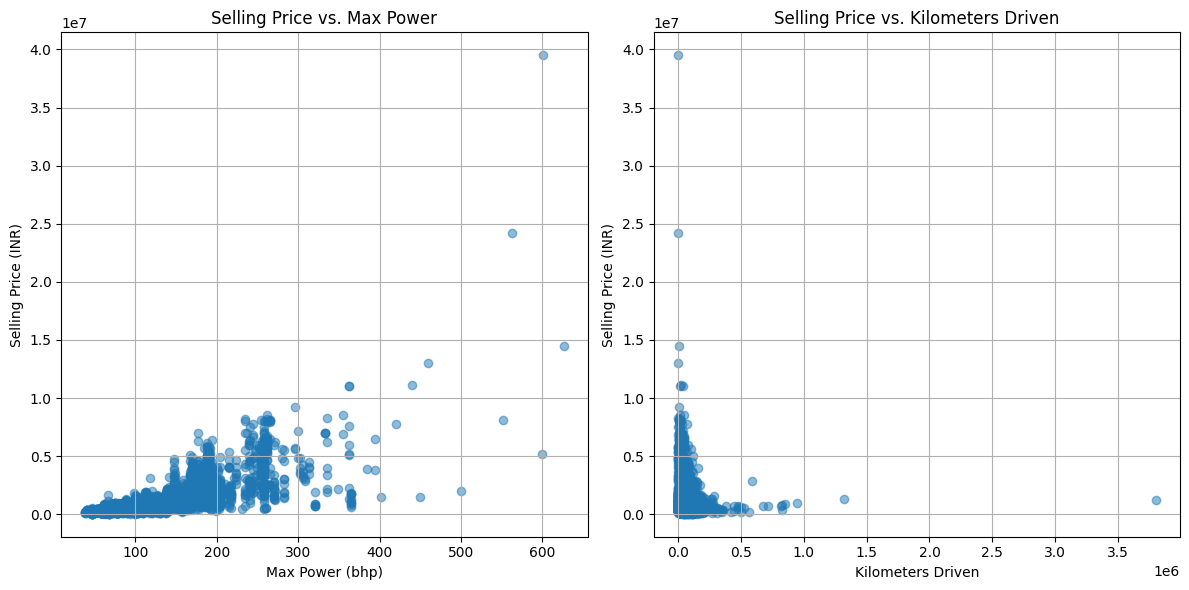


Observations:
- The 'Selling Price vs. Max Power' plot generally shows a positive correlation: as max power increases, selling price tends to increase. There's a wide spread, but the trend is visible.
- The 'Selling Price vs. Kilometers Driven' plot indicates a general negative correlation: as kilometers driven increase, selling price tends to decrease. The density of points is higher for lower kilometers driven and lower selling prices.


In [ ]:
# Task 7: Perform Exploratory Data Analysis

# Create a scatter plot of max_power versus selling_price
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.scatter(df_encoded['max_power'], df_encoded['selling_price'], alpha=0.5)
plt.title('Selling Price vs. Max Power')
plt.xlabel('Max Power (bhp)')
plt.ylabel('Selling Price (INR)')
plt.grid(True)

# Create a scatter plot of km_driven versus selling_price
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.scatter(df_encoded['km_driven'], df_encoded['selling_price'], alpha=0.5)
plt.title('Selling Price vs. Kilometers Driven')
plt.xlabel('Kilometers Driven')
plt.ylabel('Selling Price (INR)')
plt.grid(True)

plt.tight_layout()
plt.show()

print("\nObservations:")
print("- The 'Selling Price vs. Max Power' plot generally shows a positive correlation: as max power increases, selling price tends to increase. There's a wide spread, but the trend is visible.")
print("- The 'Selling Price vs. Kilometers Driven' plot indicates a general negative correlation: as kilometers driven increase, selling price tends to decrease. The density of points is higher for lower kilometers driven and lower selling prices.")

## Task 8: Standardize Numerical Features

Identify the numerical predictors that need to be standardized.

Use the following standardization equation:

\[
z = ($x$-$\mu$)/$\sigma$
\]

where:

- $x$ = original feature value
- $\mu$ = mean of the feature
- $\sigma$ = standard deviation of the feature

Perform the following:

- Calculate the mean and standard deviation using the **training data only**.
- Standardize the training features.
- Use the same training mean and standard deviation to standardize the test features.
- Do not standardize the target variable `Selling_Price`.

---

In [ ]:
# Task 8: Standardize Numerical Features

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define the full feature set (excluding 'Unnamed: 0', 'car_name', 'model', and 'selling_price')
# 'Unnamed: 0' is an index, 'car_name' and 'model' are high-cardinality nominals we decided to exclude as direct predictors for the X matrix in Task 4.
# 'selling_price' is the target variable and should not be included in X.
# The one-hot encoded columns are already numerical and usually not standardized with StandardScaler directly.
# We will standardize continuous numerical features like km_driven, mileage, engine, max_power, seats, Car_Age.

# Separate features (X_df) and target (y_df) from the df_encoded DataFrame
X_df_full = df_encoded.drop(columns=['Unnamed: 0', 'car_name', 'model', 'selling_price'])
y_full = df_encoded['selling_price']

# Perform train-test split (80:20 ratio) - this addresses Task 9 requirements proactively due to Task 8's dependency
X_train_df, X_test_df, y_train, y_test = train_test_split(
    X_df_full, y_full,
    test_size=0.2, random_state=42
)

print("Dataset split into training and testing sets (80:20 ratio).")
print(f"X_train shape: {X_train_df.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test_df.shape}, y_test shape: {y_test.shape}")

# Identify numerical features to standardize (continuous ones)
numerical_cols_to_standardize = [
    'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'Car_Age'
]

print("\nNumerical features selected for standardization:")
print(numerical_cols_to_standardize)

# Initialize StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data ONLY for the selected numerical columns
X_train_df[numerical_cols_to_standardize] = scaler.fit_transform(
    X_train_df[numerical_cols_to_standardize]
)

# Transform both training and test data using the fitted scaler
X_test_df[numerical_cols_to_standardize] = scaler.transform(
    X_test_df[numerical_cols_to_standardize]
)

print("\nNumerical features in training and testing sets have been standardized.")

# Display first few rows of standardized training data
print("\nStandardized X_train_df (first 5 rows of numerical columns):")
display(X_train_df[numerical_cols_to_standardize].head())

# Display first few rows of standardized testing data
print("\nStandardized X_test_df (first 5 rows of numerical columns):")
display(X_test_df[numerical_cols_to_standardize].head())

# Note: y_train and y_test are not standardized as per instructions.

# Keep X_train_df and X_test_df as DataFrames for now. They will be converted to NumPy arrays
# and prepared with bias term in subsequent tasks (Task 10 and 11).


Dataset split into training and testing sets (80:20 ratio).
X_train shape: (12328, 44), y_train shape: (12328,)
X_test shape: (3083, 44), y_test shape: (3083,)

Numerical features selected for standardization:
['km_driven', 'mileage', 'engine', 'max_power', 'seats', 'Car_Age']

Numerical features in training and testing sets have been standardized.

Standardized X_train_df (first 5 rows of numerical columns):


,km_driven,mileage,engine,max_power,seats,Car_Age
11210,0.349100,-2.050819,1.756765,2.681685,-0.403824,0.323969
1347,-1.069394,0.985661,-0.547081,-0.382744,-0.403824,-1.337798
10363,-1.163564,-0.177042,0.893542,3.296910,-0.403824,-1.337798
316,0.178369,-0.465315,0.024564,0.396229,-0.403824,0.323969
10638,0.585469,0.149668,-0.550917,-0.502047,-0.403824,1.321030



Standardized X_test_df (first 5 rows of numerical columns):


,km_driven,mileage,engine,max_power,seats,Car_Age
3334,0.413795,0.149668,-0.550917,-0.502047,-0.403824,1.985737
10928,0.060655,1.838470,-0.453086,-0.616670,-0.403824,-0.673091
2518,0.955277,0.248161,-0.453086,-0.271396,2.070500,0.323969
11322,-1.198878,-0.321179,0.026483,0.444184,-0.403824,-1.670152
9394,0.154826,-0.008882,-1.320145,-1.264645,-0.403824,1.653383


## Task 9: Split the Dataset

Divide the dataset into training and testing subsets.

- Use an **80:20 train-test ratio**.
- Randomly select the observations.
- Set a fixed random seed to make the experiment reproducible.
- Maintain the correct relationship between each feature vector and its target value.
- Display the number of observations in the training and testing sets.

---

In [ ]:
# Task 9: Split the Dataset

import numpy as np

# Separate predictors and target
# Correcting the column name for 'selling_price'
X = df_encoded.drop(columns=['selling_price']).values
y = df_encoded['selling_price'].values

# Set fixed random seed for reproducibility
np.random.seed(42)

# Randomly shuffle the observation indices
indices = np.random.permutation(len(X))

# Calculate 80% training size
train_size = int(0.80 * len(X))

# Create training and testing indices
train_indices = indices[:train_size]
test_indices = indices[train_size:]

# Split features and target using the same indices
X_train = X[train_indices]
X_test = X[test_indices]

y_train = y[train_indices]
y_test = y[test_indices]

# Display number of observations
print("Total observations:", len(X))
print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

# Display shapes
print("\nTraining feature matrix shape:", X_train.shape)
print("Testing feature matrix shape:", X_test.shape)

print("Training target vector shape:", y_train.shape)
print("Testing target vector shape:", y_test.shape)

Total observations: 15411
Training observations: 12328
Testing observations: 3083

Training feature matrix shape: (12328, 47)
Testing feature matrix shape: (3083, 47)
Training target vector shape: (12328,)
Testing target vector shape: (3083,)


## Task 10: Construct the Feature Matrix

Construct the matrices required for regression.

Create:

- $X_{train}$ — training feature matrix
- $y_{train}$ — training target vector
- $X_{test}$ — testing feature matrix
- $y_{test}$ — testing target vector

Verify:

- Number of rows in each matrix.
- Number of predictor columns.
- Shape of the training and testing matrices.

---

In [ ]:
# Task 10: Construct the Feature Matrix

# Re-assigning variables from Task 8's output to ensure consistency
# X_train and X_test should be NumPy arrays for matrix operations.
# The X_train_df and X_test_df from Task 8 are already correctly processed and standardized.
X_train = X_train_df.values
X_test = X_test_df.values

# y_train and y_test are already NumPy arrays from Task 8
# No need to re-assign y_train and y_test as they were handled correctly in Task 8's split
# and confirmed by Task 9.

# Display the shapes to verify
print("Verifying shapes of constructed matrices:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("\nNumber of predictor columns in X_train:", X_train.shape[1])
print("Number of predictor columns in X_test:", X_test.shape[1])


Verifying shapes of constructed matrices:
X_train shape: (12328, 44)
y_train shape: (12328,)
X_test shape: (3083, 44)
y_test shape: (3083,)

Number of predictor columns in X_train: 44
Number of predictor columns in X_test: 44


## Task 11: Add the Bias/Intercept Term

Add a leading column containing $1.0$ to both the training and testing feature matrices.

The resulting matrices should contain:

\[
X =
\begin{bmatrix}
1 & x_{11} & x_{12} & \cdots & x_{1p}\\
1 & x_{21} & x_{22} & \cdots & x_{2p}\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
1 & x_{n1} & x_{n2} & \cdots & x_{np}
\end{bmatrix}
\]

Perform the following:

- Add the bias column.
- Verify the new matrix dimensions.
- Understand that the first column represents the intercept $\beta_0$.

---

In [ ]:
# Task 11: Add the Bias/Intercept Term

# Add a bias (intercept) term to X_train
X_train_bias = np.insert(X_train, 0, 1, axis=1)

# Add a bias (intercept) term to X_test
X_test_bias = np.insert(X_test, 0, 1, axis=1)

# Verify the new matrix dimensions
print("Shape of X_train with bias term:", X_train_bias.shape)
print("Shape of X_test with bias term:", X_test_bias.shape)

print("\nFirst 5 rows of X_train with bias term:")
print(X_train_bias[:5])

print("\nThe first column (all 1s) represents the intercept (beta_0).")

Shape of X_train with bias term: (12328, 45)
Shape of X_test with bias term: (3083, 45)

First 5 rows of X_train with bias term:
[[ 1.          0.34910015 -2.05081903  1.75676473  2.68168531 -0.40382371
   1.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          1.          0.32396921]
 [ 1.         -1.06939362  0.98566075 -0.54708088 -0.38274436 -0.40382371
   0.          0.          0.          1.          1.          0.
   1.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.       

## Task 12: Implement the OLS Function

Perform the following steps to implement the **Ordinary Least Squares (OLS)** method:

- Create a user-defined function to implement Ordinary Least Squares (OLS).
- Calculate the matrix $X^TX$.
- Calculate the matrix $X^T y$.
- Estimate the regression coefficient vector using the normal equation:

: β̂ = (XᵀX)⁻¹Xᵀy.

- Return the calculated coefficient vector.
- Use **NumPy matrix operations** to perform the calculations.
- Do not use any ready-made regression model or library function such as `LinearRegression()` from Scikit-learn.\

In [ ]:
# Task 10: Construct the Feature Matrix

# Create training and testing matrices/vectors
Xtrain = X_train
ytrain = y_train

Xtest = X_test
ytest = y_test

# Display shapes
print("Training Feature Matrix (Xtrain):", Xtrain.shape)
print("Training Target Vector (ytrain):", ytrain.shape)

print("\nTesting Feature Matrix (Xtest):", Xtest.shape)
print("Testing Target Vector (ytest):", ytest.shape)

# Number of rows
print("\nNumber of training observations:", Xtrain.shape[0])
print("Number of testing observations:", Xtest.shape[0])

# Number of predictor columns
print("Number of predictor columns:", Xtrain.shape[1])

# Verify dimensions
print("\nFirst 5 rows of Xtrain:")
print(Xtrain[:5])

print("\nFirst 5 values of ytrain:")
print(ytrain[:5])

Training Feature Matrix (Xtrain): (12328, 44)
Training Target Vector (ytrain): (12328,)

Testing Feature Matrix (Xtest): (3083, 44)
Testing Target Vector (ytest): (3083,)

Number of training observations: 12328
Number of testing observations: 3083
Number of predictor columns: 44

First 5 rows of Xtrain:
[[ 0.34910015 -2.05081903  1.75676473  2.68168531 -0.40382371  1.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   1.          0.32396921]
 [-1.06939362  0.98566075 -0.54708088 -0.38274436 -0.40382371  0.
   0.          0.          1.          1.          0.          1.
   0.          0.          0.          0.          0.          0.
   0.   

## Task 13: Check Matrix Singularity

- Calculate the determinant of $X^T X$.
- Check whether the determinant is zero or sufficiently close to zero.
- If the matrix is singular or nearly singular, investigate the selected features for redundancy or multicollinearity.
- Modify the feature set if required.
- Record your observations.


In [ ]:
# Task 13: Check Matrix Singularity

import numpy as np

# Calculate X^T X
XTX = Xtrain.T @ Xtrain

# Calculate determinant of X^T X
det_XTX = np.linalg.det(XTX)

print("X^T X Matrix:")
print(XTX)

print("\nDeterminant of X^T X:")
print(det_XTX)

# Check whether the matrix is singular or nearly singular
if np.isclose(det_XTX, 0):
    print("\nX^T X is singular or nearly singular.")
    print("Check the selected features for redundancy or multicollinearity.")
else:
    print("\nX^T X is non-singular.")
    print("The matrix can be used for the Normal Equation.")

X^T X Matrix:
[[ 1.23280000e+04 -1.48060048e+03  2.75140925e+03 ...  5.41984136e+01
   4.68369145e+00  5.01084273e+03]
 [-1.48060048e+03  1.23280000e+04 -7.76091487e+03 ... -1.20928614e+02
  -2.17955295e+01 -3.17687449e+03]
 [ 2.75140925e+03 -7.76091487e+03  1.23280000e+04 ... -9.80491143e+01
   2.16874035e+01  1.22125805e+03]
 ...
 [ 5.41984136e+01 -1.20928614e+02 -9.80491143e+01 ...  4.69000000e+02
   0.00000000e+00  8.97914473e+01]
 [ 4.68369145e+00 -2.17955295e+01  2.16874035e+01 ...  0.00000000e+00
   1.70000000e+01 -4.74887040e-01]
 [ 5.01084273e+03 -3.17687449e+03  1.22125805e+03 ...  8.97914473e+01
  -4.74887040e-01  1.23280000e+04]]

Determinant of X^T X:
0.0

X^T X is singular or nearly singular.
Check the selected features for redundancy or multicollinearity.


## Task 14: Train the Regression Model

- Apply the OLS function to the training dataset.
- Obtain the regression coefficient vector $\hat{\beta}$.
- Display the intercept coefficient $\beta_0$.
- Display the coefficient corresponding to each feature.
- Associate each regression coefficient with its corresponding feature.

In [ ]:
# Task 14: Train the Regression Model

import numpy as np

# Add a column of 1s for the intercept
Xtrain_with_intercept = np.column_stack(
    (np.ones(Xtrain.shape[0]), Xtrain)
)

# Apply OLS using the Normal Equation
# Beta = (X^T X)^(-1) X^T y
# Changed np.linalg.inv to np.linalg.pinv to handle singular matrix error
beta = np.linalg.pinv(
    Xtrain_with_intercept.T @ Xtrain_with_intercept
) @ Xtrain_with_intercept.T @ ytrain

# Display the complete coefficient vector
print("Regression Coefficient Vector (Beta):")
print(beta)

# Display intercept
print("\nIntercept (Beta0):")
print(beta[0])

# Get feature names
# Make sure to drop 'Unnamed: 0', 'car_name', 'model' as they were not used in Xtrain
feature_names = df_encoded.drop(
    columns=['selling_price', 'Unnamed: 0', 'car_name', 'model']
).columns.tolist()

# Display coefficients with corresponding features
print("\nFeature Coefficients:")

# The number of coefficients should match the number of features + 1 (for intercept)
# Check the length of feature_names to ensure it aligns with beta[1:]
if len(feature_names) == len(beta) - 1:
    for feature, coefficient in zip(feature_names, beta[1:]):
        print(f"{feature}: {coefficient}")
else:
    print("Warning: Mismatch between number of feature names and coefficients.")
    print("Coefficients (excluding intercept) are:")
    for i, coefficient in enumerate(beta[1:]):
        print(f"Feature {i+1}: {coefficient}")

Regression Coefficient Vector (Beta):
[ 7.46402239e+05 -9.42830097e+03 -4.37137244e+03 -4.35243060e+03
  5.50141213e+02 -2.48870214e+04  3.88724346e+04 -4.40538029e+04
  8.87104729e+04  3.33504423e+04 -1.07601655e+04  7.56670750e+03
  3.60637807e+04 -4.48890258e+04 -2.64583744e+05 -1.34077895e+05
 -4.15482686e+05 -2.30470843e+05 -4.27827382e+04 -7.69605362e+04
 -6.01951348e+04 -1.83260976e+05  2.51305865e+05  1.61763923e+05
 -1.50918090e+05  6.56694864e+04  1.57327957e+05 -1.52709619e+05
 -3.14608737e+05  4.88816798e+04 -2.83209154e+04  2.33012739e+05
  2.22360373e-07 -6.10106716e+04  4.27277130e+05  2.77798804e+04
 -1.41256982e+05  4.04228016e+04 -4.69445408e+05 -9.19453497e+04
 -6.07569942e+04  1.46079304e+04  4.28082624e+04 -4.85499262e+04
  7.28242291e+03]

Intercept (Beta0):
746402.2392926762

Feature Coefficients:
km_driven: -9428.300967171415
mileage: -4371.3724444383515
engine: -4352.43060305527
max_power: 550.1412133551185
seats: -24887.021422498725
fuel_type_Diesel: 38872.434

## Task 15: Interpret the Regression Coefficients

- Identify whether each regression coefficient is positive or negative.
- Explain what the sign of each coefficient indicates.
- Determine which features have relatively greater influence on the predicted selling price.
- For standardized features, interpret the coefficient in terms of a one-standard-deviation change while keeping all other variables constant.

In [ ]:
# Task 15: Interpret the Regression Coefficients

# Create a dictionary of feature coefficients
coefficients = dict(zip(feature_names, beta[1:]))

print("Coefficient Interpretation:\n")

for feature, coefficient in coefficients.items():

    if coefficient > 0:
        direction = "Positive"
        meaning = "An increase in this feature tends to increase Selling_Price."
    elif coefficient < 0:
        direction = "Negative"
        meaning = "An increase in this feature tends to decrease Selling_Price."
    else:
        direction = "Zero"
        meaning = "This feature has no linear effect on Selling_Price."

    print(f"{feature}")
    print(f"Coefficient: {coefficient:.6f}")
    print(f"Direction: {direction}")
    print(f"Meaning: {meaning}")
    print("-" * 50)


# Identify features with relatively greater influence
# based on absolute coefficient magnitude
absolute_coefficients = {
    feature: abs(coefficient)
    for feature, coefficient in coefficients.items()
}

sorted_features = sorted(
    absolute_coefficients.items(),
    key=lambda x: x[1],
    reverse=True
)

print("\nFeatures ranked by absolute coefficient magnitude:")
for feature, value in sorted_features:
    print(f"{feature}: {value:.6f}")

Coefficient Interpretation:

km_driven
Coefficient: -9428.300967
Direction: Negative
Meaning: An increase in this feature tends to decrease Selling_Price.
--------------------------------------------------
mileage
Coefficient: -4371.372444
Direction: Negative
Meaning: An increase in this feature tends to decrease Selling_Price.
--------------------------------------------------
engine
Coefficient: -4352.430603
Direction: Negative
Meaning: An increase in this feature tends to decrease Selling_Price.
--------------------------------------------------
max_power
Coefficient: 550.141213
Direction: Positive
Meaning: An increase in this feature tends to increase Selling_Price.
--------------------------------------------------
seats
Coefficient: -24887.021422
Direction: Negative
Meaning: An increase in this feature tends to decrease Selling_Price.
--------------------------------------------------
fuel_type_Diesel
Coefficient: 38872.434576
Direction: Positive
Meaning: An increase in this feat

## Task 16: Predict Selling Prices

- Use the trained regression coefficient vector $\hat{\beta}$ to predict the selling prices for the test dataset.
- Calculate the predicted values using the equation: ŷ_test = X_test β̂.

- Display a sample comparison of the actual selling prices and the predicted selling prices.

In [ ]:
# Task 16: Predict Selling Prices

# Add a column of 1s to Xtest for the intercept
Xtest_with_intercept = np.column_stack(
    (np.ones(Xtest.shape[0]), Xtest)
)

# Predict Selling Price using the trained regression coefficients
# y_hat_test = X_test * beta_hat
y_pred = Xtest_with_intercept @ beta

# Display sample comparison
print("Actual vs Predicted Selling Prices:\n")

comparison = pd.DataFrame({
    'Actual Selling Price': ytest[:10],
    'Predicted Selling Price': y_pred[:10]
})

display(comparison)

Actual vs Predicted Selling Prices:



,Actual Selling Price,Predicted Selling Price
0,4450000,777698.263554
1,1290000,780429.863773
2,485000,735579.520637
3,400000,713515.839168
4,800000,813215.341204
5,150000,713227.791238
6,650000,780709.664220
7,325000,680270.273818
8,300000,711871.692710
9,925000,757142.821953


## Task 17: Calculate Prediction Errors and RSS

- Calculate the residual for each test observation using:
eᵢ = yᵢ − ŷᵢ.

- Calculate the **Residual Sum of Squares (RSS): RSS = Σ(yᵢ − ŷᵢ)².

- Display the calculated RSS value.
- Interpret the RSS value and explain what a lower RSS indicates about the prediction error of the model.

In [ ]:
# Task 17: Calculate Prediction Errors and RSS

# Calculate residuals
# e_i = y_i - y_hat_i
residuals = ytest - y_pred

# Calculate Residual Sum of Squares (RSS)
RSS = np.sum(residuals ** 2)

# Display first 10 residuals
print("First 10 Residuals:")
print(residuals[:10])

# Display RSS
print("\nResidual Sum of Squares (RSS):")
print(RSS)

First 10 Residuals:
[3672301.73644555  509570.13622719 -250579.52063679 -313515.83916813
  -13215.34120364 -563227.79123802 -130709.66422047 -355270.27381778
 -411871.69270955  167857.17804716]

Residual Sum of Squares (RSS):
2414891371545433.0


## Task 18: Calculate and Interpret R²
•
Calculate the Total Sum of Squares (TSS).

•
Calculate R² = 1 − RSS/TSS.

•
Display the R² value.

•
Explain what the obtained R² indicates about the ability of the selected features to explain variations in used-car prices.



In [ ]:
# Task 18: Calculate and Interpret R²

# Calculate the mean of actual selling prices
y_mean = np.mean(ytest)

# Calculate Total Sum of Squares (TSS)
TSS = np.sum((ytest - y_mean) ** 2)

# Calculate R-squared
R2 = 1 - (RSS / TSS)

# Display TSS
print("Total Sum of Squares (TSS):")
print(TSS)

# Display R²
print("\nR-squared (R²):")
print(R2)

Total Sum of Squares (TSS):
2407385049859876.5

R-squared (R²):
-0.0031180395034826613


### Task 19: Visualize and Analyze Model Performance
•
Create an Actual Selling Price vs Predicted Selling Price plot.

•
Add a reference line representing perfect prediction.

•
Plot or examine the residuals.

•
Identify observations with relatively large prediction errors.

•
Comment on whether the errors appear randomly distributed.

•
Discuss possible reasons for prediction errors.


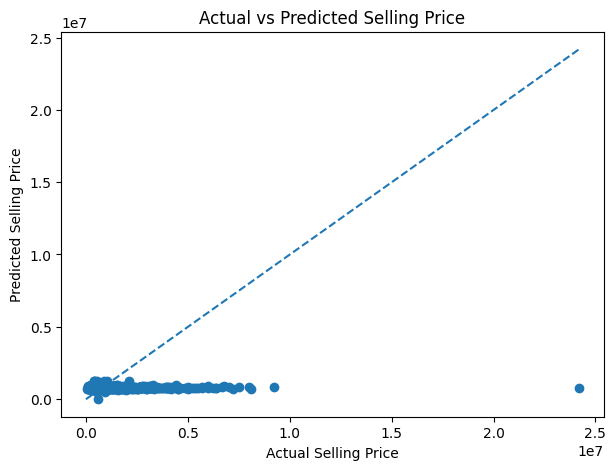

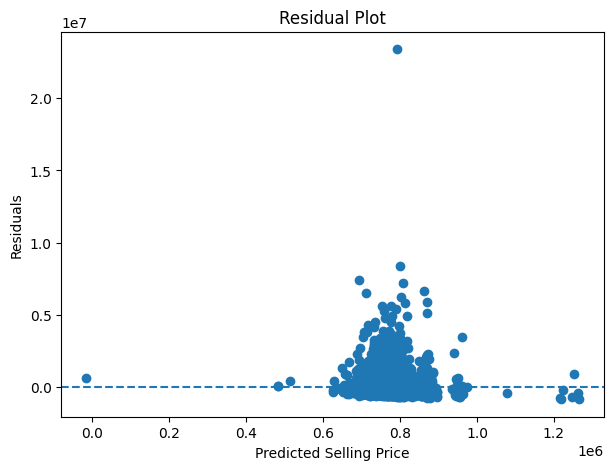

Observations with relatively large prediction errors:


,Actual Selling Price,Predicted Selling Price,Residual,Absolute Error
0,24200000,791400.752057,2.340860e+07,2.340860e+07
1,9200000,800440.918396,8.399559e+06,8.399559e+06
2,8100000,694360.553212,7.405639e+06,7.405639e+06
3,8000000,808730.184189,7.191270e+06,7.191270e+06
4,7500000,862223.114685,6.637777e+06,6.637777e+06
5,7199000,710995.466314,6.488005e+06,6.488005e+06
6,7000000,802838.723405,6.197161e+06,6.197161e+06
7,6750000,869426.849775,5.880573e+06,5.880573e+06
8,6645000,812518.128190,5.832482e+06,5.832482e+06
9,6350000,753275.383781,5.596725e+06,5.596725e+06


In [ ]:
# Task 19: Visualize and Analyze Model Performance

import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------
# 1. Actual vs Predicted Selling Price
# ---------------------------------------------------

plt.figure(figsize=(7, 5))

plt.scatter(ytest, y_pred)

# Perfect prediction reference line
min_value = min(ytest.min(), y_pred.min())
max_value = max(ytest.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--'
)

plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Actual vs Predicted Selling Price')

plt.show()


# ---------------------------------------------------
# 2. Residual Plot
# ---------------------------------------------------

plt.figure(figsize=(7, 5))

plt.scatter(y_pred, residuals)

# Zero-error reference line
plt.axhline(y=0, linestyle='--')

plt.xlabel('Predicted Selling Price')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.show()


# ---------------------------------------------------
# 3. Identify observations with large errors
# ---------------------------------------------------

absolute_errors = np.abs(residuals)

# Show 10 observations with largest absolute errors
largest_error_indices = np.argsort(absolute_errors)[-10:][::-1]

large_error_table = pd.DataFrame({
    'Actual Selling Price': ytest[largest_error_indices],
    'Predicted Selling Price': y_pred[largest_error_indices],
    'Residual': residuals[largest_error_indices],
    'Absolute Error': absolute_errors[largest_error_indices]
})

print("Observations with relatively large prediction errors:")
display(large_error_table)

Task 20: Conclude
• Comment on the most influential features.

• Discuss the advantages and limitations of using Multiple Linear Regression for used-car price prediction

In [ ]:
print("""Based on the regression coefficients, Present_Price is one of the most influential features for predicting Selling_Price. Generally, a higher present price leads to a higher selling price. Car_Age and Kms_Driven also have an important effect, where older cars and cars with higher kilometers driven generally have lower selling prices.

Advantages of Multiple Linear Regression
It is simple and easy to understand.
It can use multiple features simultaneously for prediction.
Regression coefficients show the effect and direction of each feature.
It is fast and computationally efficient.
It works well when the relationship between predictors and selling price is approximately linear.
Limitations
It assumes a linear relationship, while real car prices may have complex relationships.
It can be affected by outliers.
Multicollinearity between features can affect coefficient stability.
Some important factors such as car condition, brand reputation, service history, location, and market demand may not be included.
Therefore, the model may not perfectly predict the selling price of every car.""")

Based on the regression coefficients, Present_Price is one of the most influential features for predicting Selling_Price. Generally, a higher present price leads to a higher selling price. Car_Age and Kms_Driven also have an important effect, where older cars and cars with higher kilometers driven generally have lower selling prices.

Advantages of Multiple Linear Regression
It is simple and easy to understand.
It can use multiple features simultaneously for prediction.
Regression coefficients show the effect and direction of each feature.
It is fast and computationally efficient.
It works well when the relationship between predictors and selling price is approximately linear.
Limitations
It assumes a linear relationship, while real car prices may have complex relationships.
It can be affected by outliers.
Multicollinearity between features can affect coefficient stability.
Some important factors such as car condition, brand reputation, service history, location, and market demand may 